In [79]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd

In [81]:
df = pd.DataFrame([[10,6,12], [11,4,9],[8,5,10],[3,3,2.5], [2,2.8,1.3],[1,1,2]], columns=['gene1','gene2','gene3'])
df

,gene1,gene2,gene3
0,10,6.0,12.0
1,11,4.0,9.0
2,8,5.0,10.0
3,3,3.0,2.5
4,2,2.8,1.3
5,1,1.0,2.0


In [83]:
X = df.values

Text(0.5, 0, 'PC3')

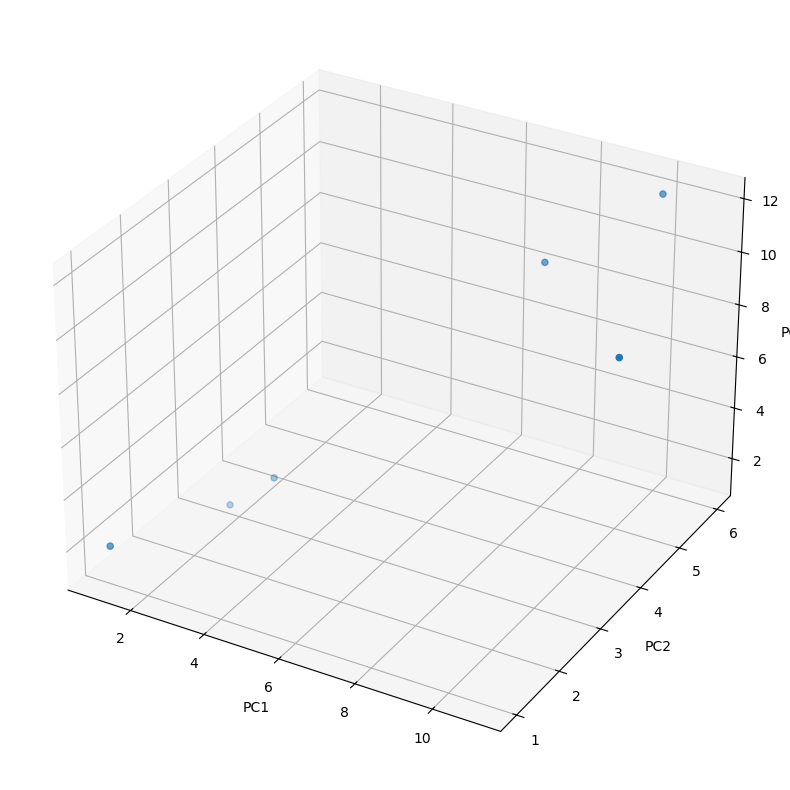

In [85]:
# import relevant libraries for 3d graph
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))
 
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
 
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
axis.scatter(X[:,0],X[:,1],X[:,2])
axis.set_xlabel("PC1", fontsize=10)
axis.set_ylabel("PC2", fontsize=10)
axis.set_zlabel("PC3", fontsize=10)

In [95]:
pca = PCA(n_components=2, svd_solver='full')
pca.fit(df)

PCA(n_components=2, svd_solver='full')

In [97]:
X_pca = pca.fit_transform(X)
X_pca

array([[ 7.50252543, -1.02647403],
       [ 5.52302054,  2.11403452],
       [ 4.51821683, -1.04258047],
       [-4.60876703,  0.15688518],
       [-6.1707374 ,  0.15749233],
       [-6.76425837, -0.35935752]])

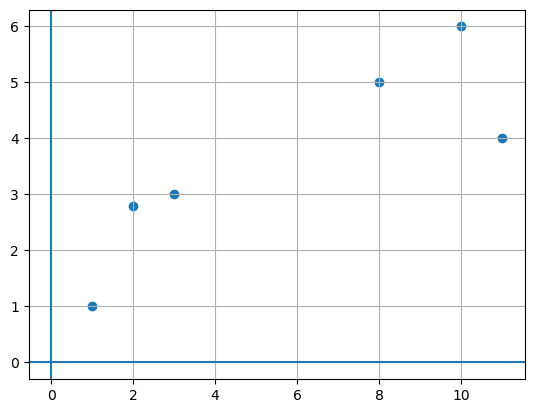

In [99]:
plt.scatter(X[:,0], X[:,1])
plt.grid(True)
plt.axhline()
plt.axvline()

Tỉ lệ phương sai được giải thích bởi các thành phần chính: [0.72962445 0.22850762]
Tổng tỉ lệ phương sai được giải thích: 0.9581320720000165
        PC1       PC2  target
0 -2.264703  0.480027       0
1 -2.080961 -0.674134       0
2 -2.364229 -0.341908       0
3 -2.299384 -0.597395       0
4 -2.389842  0.646835       0
(150, 3)


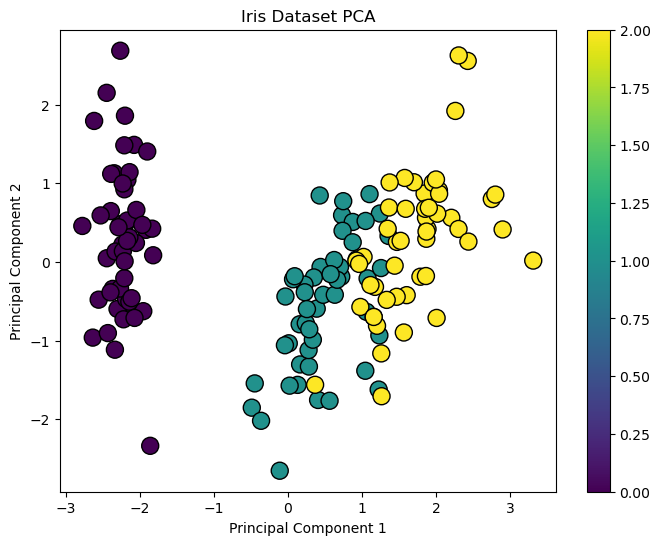

In [101]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Load dữ liệu Iris
iris = load_iris()
X = iris.data
y = iris.target

# Chuẩn hóa dữ liệu (vì PCA nhạy cảm với scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Khởi tạo PCA để giảm xuống còn 2 thành phần chính
pca = PCA(n_components=2)

# Fit và transform dữ liệu
X_pca = pca.fit_transform(X_scaled)

# In ra phần trăm phương sai được giải thích bởi từng thành phần chính
print("Tỉ lệ phương sai được giải thích bởi các thành phần chính:", pca.explained_variance_ratio_)
print("Tổng tỉ lệ phương sai được giải thích:", sum(pca.explained_variance_ratio_))

# Chuyển thành DataFrame để tiện trực quan hóa
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y

# In kết quả
print(df_pca.head())
print(df_pca.shape)

# Trực quan hóa dữ liệu sau khi giảm chiều
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=y, cmap='viridis', edgecolor='k', s=150)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Iris Dataset PCA')
plt.colorbar()
plt.show()
